<a href="https://colab.research.google.com/github/MohammedZaid-AI/Smart-Coffee-Recommender/blob/master/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

In [3]:
data=pd.read_csv("/content/Coffe_sales _updated.csv")

In [4]:
data.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,01-03-2024,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,01-03-2024,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,01-03-2024,20:18.1
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,01-03-2024,46:33.0
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,01-03-2024,48:14.6


In [5]:
data.shape

(3547, 11)

In [6]:
data.isnull().sum()

,0
hour_of_day,0
cash_type,0
money,4
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0


In [7]:
data['money']=data['money'].fillna(data['money'].mean())

Here’s your content reorganized into a clean, structured format:

---

## **Handling Missing Data**

### **1. Directional Filling (Time Series / Sequential Data)**

Used when data has an inherent order (e.g., stock prices, sensor readings).

* **Forward Fill (ffill)**
  Propagates the last valid observation forward to fill missing values.

  ```python
  df.fillna(method='ffill')
  ```

* **Backward Fill (bfill)**
  Uses the next valid observation to fill missing values backward.

  ```python
  df.fillna(method='bfill')
  ```

---

### **2. Statistical Imputation**

Replaces missing values with summary statistics to preserve dataset size and avoid dropping data.

* **Mean (Average)**
  Suitable for numerical data without extreme outliers.

  ```python
  df['column'].fillna(df['column'].mean())
  ```

* **Median**
  More robust for skewed numerical data or when outliers are present.

  ```python
  df['column'].fillna(df['column'].median())
  ```

* **Mode (Most Frequent Value)**
  Best for categorical data (e.g., strings).

  ```python
  df['column'].fillna(df['column'].mode()[0])
  ```

---

If you want, I can also turn this into a comparison table or add when to use each method in real scenarios.


In [8]:
data.isnull().sum()

,0
hour_of_day,0
cash_type,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0


In [9]:
data['day_of_the_week']=pd.to_datetime(data['Date'], dayfirst=True).dt.dayofweek

In [10]:
def get_time_of_day(hour):
  if 5 <= hour <= 12:
    return "Morning"
  elif 13 <= hour <= 16:
    return "Afternoon"
  else:
    return "Evening"

In [11]:
data['hour']=data['hour_of_day']
data['time_of_day']=data['hour'].apply(get_time_of_day)

In [12]:
data.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,day_of_the_week,hour,time_of_day
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,01-03-2024,15:50.5,4,10,Morning
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,01-03-2024,19:22.5,4,12,Morning
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,01-03-2024,20:18.1,4,12,Morning
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,01-03-2024,46:33.0,4,13,Afternoon
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,01-03-2024,48:14.6,4,13,Afternoon


In [13]:
data.shape

(3547, 14)

In [14]:
x=data[['day_of_the_week','time_of_day']]
y=data['coffee_name']

In [15]:
le_time = LabelEncoder()
le_day = LabelEncoder()
le_coffee = LabelEncoder()
x.loc[:,'day_of_the_week']=le_day.fit_transform(x['day_of_the_week'])
x.loc[:,'time_of_day']=le_time.fit_transform(x['time_of_day'])
y=le_coffee.fit_transform(y)

/tmp/ipykernel_5327/1592106926.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 ... 6 6 6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  x.loc[:,'day_of_the_week']=le_day.fit_transform(x['day_of_the_week'])


In [16]:
display(x.head())

,day_of_the_week,time_of_day
0,4,2
1,4,2
2,4,2
3,4,0
4,4,0


In [17]:
model=RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x,y)


RandomForestClassifier(random_state=42)

In [18]:
def predict_coffee(day_of_the_week, time_of_day):
  day_of_the_week_encoded=le_day.transform([day_of_the_week])[0]
  time_of_day_encoded=le_time.transform([time_of_day])[0]

  predict=model.predict([[day_of_the_week_encoded, time_of_day_encoded]])
  return le_coffee.inverse_transform(predict)[0]

In [19]:
joblib.dump(model, "coffee_model.pkl")

['coffee_model.pkl']

In [20]:
joblib.dump(le_day, "le_day.pkl")

['le_day.pkl']

In [21]:
joblib.dump(le_time, "le_time.pkl")

['le_time.pkl']

In [22]:
joblib.dump(le_coffee, "le_coffee.pkl")

['le_coffee.pkl']

## Data Visualization: Most Popular Coffee by Day and Time

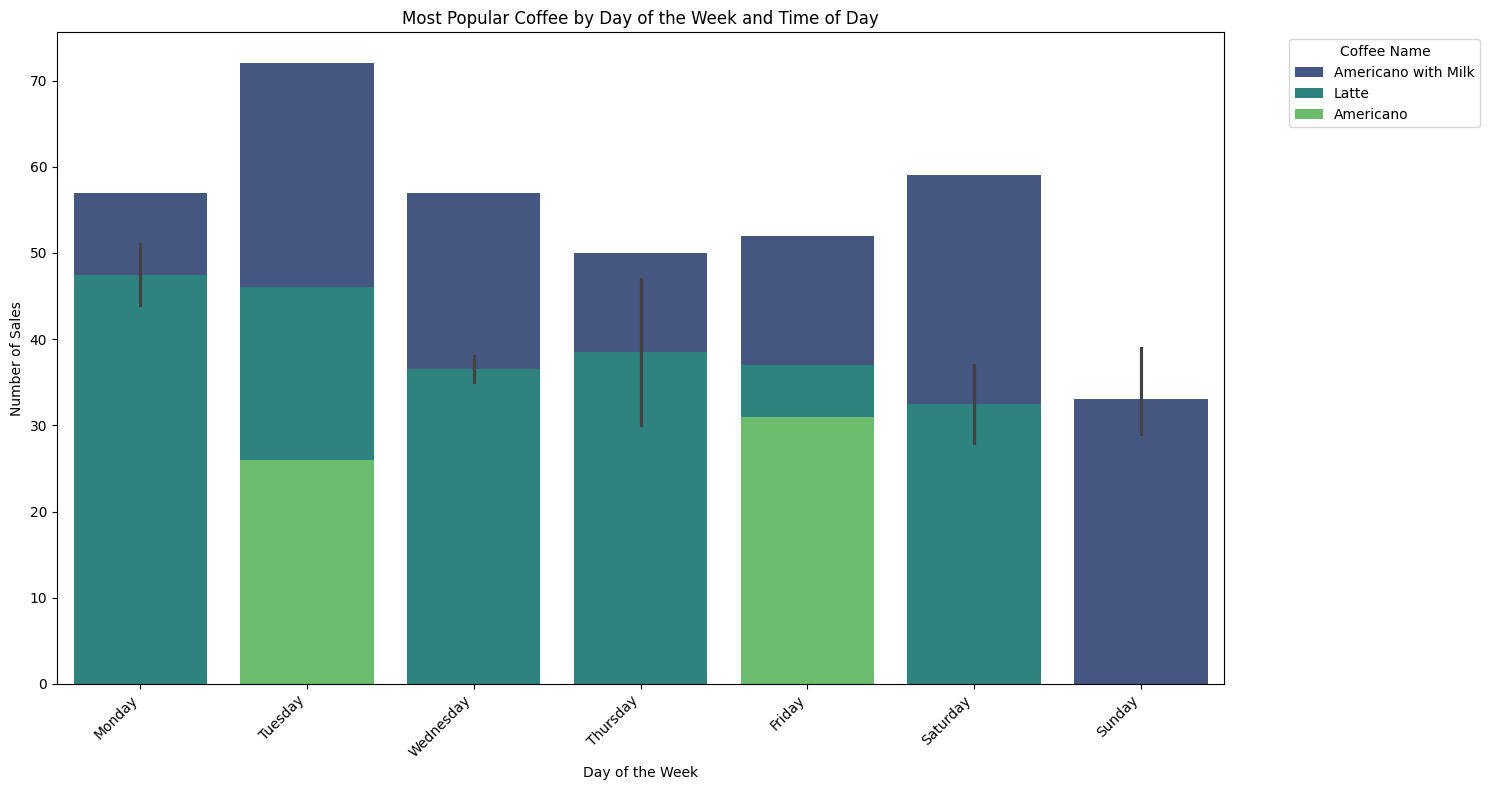

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the get_time_of_day function again to ensure it's available
def get_time_of_day(hour):
  if 5 <= hour <= 12:
    return "Morning"
  elif 13 <= hour <= 16:
    return "Afternoon"
  else:
    return "Evening"

# Reload data and perform necessary preprocessing steps
data = pd.read_csv("/content/Coffe_sales _updated.csv")
data['money'] = data['money'].fillna(data['money'].mean())
data['day_of_the_week'] = pd.to_datetime(data['Date'], dayfirst=True).dt.dayofweek
data['hour'] = data['hour_of_day']
data['time_of_day'] = data['hour'].apply(get_time_of_day)

# Group data to find the most frequent coffee for each day and time
coffee_popularity = data.groupby(['day_of_the_week', 'time_of_day', 'coffee_name']).size().reset_index(name='count')

# Find the most popular coffee for each day and time combination
idx = coffee_popularity.groupby(['day_of_the_week', 'time_of_day'])['count'].idxmax()
most_popular_coffee = coffee_popularity.loc[idx].reset_index(drop=True)

# Map numerical day of the week to actual day names for better readability
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
most_popular_coffee['day_name'] = most_popular_coffee['day_of_the_week'].map(day_names)

# Order time of day for better visualization
time_of_day_order = ['Morning', 'Afternoon', 'Evening']
most_popular_coffee['time_of_day'] = pd.Categorical(most_popular_coffee['time_of_day'], categories=time_of_day_order, ordered=True)

# Sort by day and then by time of day
most_popular_coffee = most_popular_coffee.sort_values(by=['day_of_the_week', 'time_of_day'])

# Create the bar plot
plt.figure(figsize=(15, 8))
sns.barplot(x='day_name', y='count', hue='coffee_name', data=most_popular_coffee,
            palette='viridis', dodge=False)

plt.title('Most Popular Coffee by Day of the Week and Time of Day')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Coffee Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()